In [1]:
import pandas as pd

df = pd.read_json("CAIL2018_ALL_DATA/final_all_data/first_stage/train.json", lines=True)

In [2]:
# Normnalise the dataset

df2 = pd.json_normalize(df["meta"])

In [3]:
reformatted = pd.concat([df["fact"], df2], axis=1)

reformatted.head(5)

,fact,punish_of_money,criminals,accusation,relevant_articles,term_of_imprisonment.life_imprisonment,term_of_imprisonment.death_penalty,term_of_imprisonment.imprisonment
0,公诉机关指控：2016年3月28日20时许，被告人颜某在本市洪山区马湖新村足球场马路边捡拾到...,1000,[颜某],[盗窃],[264],False,False,4
1,天津市静海县人民检察院指控，2014年5月13日上午8时许，被告人李xx在天津市静海县大邱庄...,0,[李xx],[盗窃],[264],False,False,0
2,永顺县人民检察院指控，2014年1月11日，被告人李某某与彭某某（另案处理）在永顺县塔卧镇“...,0,[李某某],[强奸],[236],False,False,144
3,公诉机关起诉书指控：\r\n2016年11月17日凌晨1时许，被告人周某在本县武康街道营盘小...,5000,[周某],[盗窃],[264],False,False,6
4,大名县人民检察院起诉书指控，2014年3月25日9时许，被告人张某在自家庄某处因故与本村席某...,0,[张某],[故意伤害],[234],False,False,21


In [4]:
# Get how many unique accusations there are
reformatted['accusation_tuple'] = reformatted['accusation'].dropna().apply(
    lambda x: tuple(sorted(x)) if isinstance(x, list) else (x,)
)

unique_combinations = reformatted['accusation_tuple'].unique()
print(f"Found {len(unique_combinations)} unique combinations.")
for combo in unique_combinations:
    print(combo)

Found 3683 unique combinations.
('盗窃',)
('强奸',)
('故意伤害',)
('故意伤害', '盗窃')
('诈骗',)
('故意伤害', '故意毁坏财物')
('非法侵入住宅',)
('虚开增值税专用发票、用于骗取出口退税、抵扣税款发票',)
('猥亵儿童',)
('开设赌场', '盗窃')
('受贿', '诈骗')
('寻衅滋事',)
('盗窃', '诈骗')
('容留他人吸毒',)
('危险驾驶',)
('职务侵占',)
('妨害信用卡管理', '诈骗')
('危险驾驶', '盗窃')
('强迫交易', '诈骗')
('开设赌场', '故意伤害')
('寻衅滋事', '故意伤害')
('抢劫', '抢夺', '盗窃')
('伪造、变造居民身份证', '盗窃')
('强奸', '抢劫')
('掩饰、隐瞒犯罪所得、犯罪所得收益', '盗窃')
('抢劫', '故意伤害')
('妨害公务', '故意伤害')
('抢劫', '盗窃')
('抢夺', '盗窃')
('盗窃', '非法持有毒品')
('妨害作证', '故意伤害')
('挪用资金',)
('敲诈勒索', '盗窃')
('放火', '盗窃')
('合同诈骗',)
('信用卡诈骗',)
('强迫交易', '盗窃')
('故意伤害', '诈骗')
('故意伤害', '聚众斗殴', '非法持有、私藏枪支、弹药')
('贪污',)
('信用卡诈骗', '盗窃')
('强奸', '盗窃')
('故意伤害', '非法持有、私藏枪支、弹药')
('强奸', '故意伤害')
('传播淫秽物品', '制造、贩卖、传播淫秽物品')
('危险驾驶', '故意伤害')
('行贿', '诈骗')
('敲诈勒索',)
('侵占', '盗窃')
('抢夺', '诈骗')
('伪造、变造、买卖国家机关公文、证件、印章',)
('强奸', '诈骗')
('故意伤害', '非法拘禁')
('故意毁坏财物', '盗窃')
('盗窃', '走私、贩卖、运输、制造毒品')
('盗窃', '非法侵入住宅')
('抢劫',)
('容留他人吸毒', '盗窃')
('掩饰、隐瞒犯罪所得、犯罪所得收益', '诈骗')
('抢夺',)
('交通肇事', '故意伤害')
('故意杀人',)
('故意伤害', '窝藏、包庇')

accusation_tuple
(盗窃,)                             363225
(危险驾驶,)                           334103
(故意伤害,)                           189253
(交通肇事,)                           161663
(走私、贩卖、运输、制造毒品,)                  117768
(容留他人吸毒,)                          54427
(诈骗,)                              51507
(寻衅滋事,)                            32019
(信用卡诈骗,)                           21452
(抢劫,)                              21107
(妨害公务,)                            17386
(非法持有、私藏枪支、弹药,)                    17148
(非法持有毒品,)                          16471
(开设赌场,)                            15883
(掩饰、隐瞒犯罪所得、犯罪所得收益,)                12470
(滥伐林木,)                            11174
(受贿,)                              10728
(故意毁坏财物,)                           9824
(抢夺,)                               8194
(赌博,)                               7776
(非法拘禁,)                             7172
(职务侵占,)                             7140
(故意杀人,)                             6969
(生产、销售假药,)                          6630

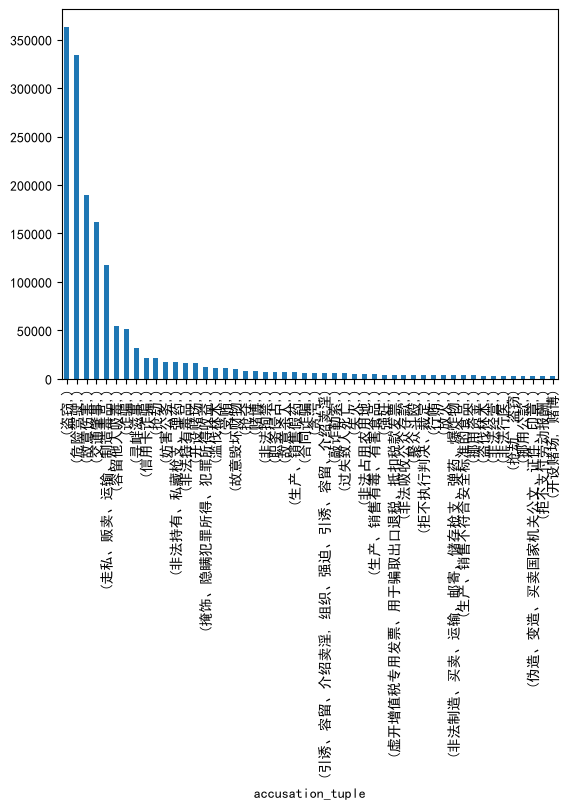

In [5]:
# Visualise the ranked distribution of different combinations
import matplotlib.pyplot as plt
from matplotlib import font_manager
font_path = 'SimHei.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['font.sans-serif'] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False 

agg_combinations = reformatted['accusation_tuple'].value_counts().head(50)
print(agg_combinations)
agg_combinations.plot(kind='bar')

plt.show()


In [8]:
# Generate different dataset samples

# Attempt 1: Stratified Sampling by type of crime

min_class_size = reformatted['accusation_tuple'].value_counts().min()

stratified_sample = reformatted.groupby('accusation_tuple', group_keys= True).sample(frac = 0.03, random_state=21)

print(stratified_sample['accusation_tuple'].value_counts().head(50))
print(stratified_sample.count)


accusation_tuple
(盗窃,)                             10897
(危险驾驶,)                           10023
(故意伤害,)                            5678
(交通肇事,)                            4850
(走私、贩卖、运输、制造毒品,)                   3533
(容留他人吸毒,)                          1633
(诈骗,)                              1545
(寻衅滋事,)                             961
(信用卡诈骗,)                            644
(抢劫,)                               633
(妨害公务,)                             522
(非法持有、私藏枪支、弹药,)                     514
(非法持有毒品,)                           494
(开设赌场,)                             476
(掩饰、隐瞒犯罪所得、犯罪所得收益,)                 374
(滥伐林木,)                             335
(受贿,)                               322
(故意毁坏财物,)                           295
(抢夺,)                               246
(赌博,)                               233
(非法拘禁,)                             215
(职务侵占,)                             214
(故意杀人,)                             209
(生产、销售假药,)                          199
(合同诈骗,)                

In [7]:
# Attempt 2: Balanced Sampling by type of crime
min_class_size = 200


processed_chunks = []


for group_name, group_data in reformatted.groupby('accusation_tuple'):
    
    if len(group_data) > min_class_size:
        processed_chunks.append(group_data.sample(n=min_class_size, random_state=42))
        
    # If it is smaller or equal, keep the whole thing untouched
    else:
        processed_chunks.append(group_data)

capped_data = pd.concat(processed_chunks, ignore_index=True)

print(capped_data['accusation_tuple'].value_counts())
print(capped_data.count())

accusation_tuple
(交通肇事,)                                         200
(以危险方法危害公共安全,)                                  200
(传播淫秽物品, 制作、复制、出版、贩卖、传播淫秽物品牟利, 制造、贩卖、传播淫秽物品)    200
(传播淫秽物品, 制造、贩卖、传播淫秽物品)                          200
(伪造、变造、买卖国家机关公文、证件、印章,)                         200
                                               ... 
(非法收购、运输盗伐、滥伐的林木, 非法采矿)                           1
(非法猎捕、杀害珍贵、濒危野生动物, 非法采伐、毁坏国家重点保护植物)               1
(非法经营, 非法获取公民个人信息)                                1
(非法采矿, 骗取贷款、票据承兑、金融票证)                            1
(骗取贷款、票据承兑、金融票证, 高利转贷)                            1
Name: count, Length: 3683, dtype: int64
fact                                      54936
punish_of_money                           54936
criminals                                 54936
accusation                                54936
relevant_articles                         54936
term_of_imprisonment.life_imprisonment    54936
term_of_imprisonment.death_penalty        54936
term_of_imprisonment.imprisonment  

In [9]:
# Process Attempt 1 first
import numpy as np
np.set_printoptions(threshold=np.inf)

first_row = stratified_sample.iloc[0]
with pd.option_context('display.max_columns', None, 'display.max_colwidth', None):
    print(first_row)


fact                                      长乐市人民检察院指控：\r\n2012年2月至2013年2月，林某1、林某2（均已起诉）等长乐市漳港街道沙尾村干部，利用协助长乐市漳港街道从事长乐市漳港街道滨江滨海路沙尾段填土方工程项目征地、填土方招标的职务便利，在长乐市漳港街道滨江滨海路沙尾段填土方工程的征地、招投标和工程款（长乐市滨江滨海路南北澳至松下段建设指挥部财政全额拨款）结算过程中，与作为填土方工程承包人的一方被告人王某事先通谋，采取围标的方式，虚高该填土方工程造价，共同骗取工程款。在此过程中，被告人王某在该工程招标环节以围标的方式虚高工程造价，并在工程款结算时经手开具虚假发票，帮助林某1、林某2等人顺利通过工程结算从中骗取工程款计人民币1334577元。被告人王某未从中分得款项。\r\n2015年3月13日，被告人王某在长乐市万业锦江城12座1201室被抓获。\r\n针对指控的上述事实，公诉机关提供了被告人王某的供述，证人林某1、林某2、陈某1、陈某2、林某3等人证言，会议纪要、报告，凭证、收据、银行流水账单，测绘报告，长乐市单项用款计划审批表及凭证，说明，任职证明，到案经过，户籍证明等证据材料。\r\n公诉机关认为，被告人王某利用他人的职务便利，共同贪污计人民币1334577元，其行为已触犯了《中华人民共和国刑法》××××、××、××××、××之规定，犯罪事实清楚，证据确实充分，应以贪污罪追究其刑事责任。被告人王某在共同犯罪中起次要作用，是从犯，根据《中华人民共和国刑法》××之规定，应当从轻、减轻处罚或者免除处罚。提请本院依法判处。\r\n
punish_of_money                                                                                                                                                                                                                                                                                       

In [9]:
# What do to 
# Place article into both lawyers points 
# Secure outcome info
# Secure process rewards, Gemini AI needs to output it in json format, similar to the paper
# extract fact
# need to run this on a 

In [10]:
# data analysis
vc = stratified_sample['fact'].value_counts().reset_index()
vc.columns = ["text", "freq"]

vc['char_length'] = vc['text'].str.len()
vc_sorted = vc.sort_values(by='char_length', ascending=True)
print(vc_sorted)
vc_sorted.to_csv("counts.txt")


                                                    text  freq  char_length
5954                                   再审查明的事实与原审一致。\r\n     1           15
21349                                再审中公诉机关坚持原指控意见。\r\n     1           17
43632                                 \n经二审审理查明的事实与一审相同。     1           17
3441                                \n二审查明的其他事实及证据与一审相同。     1           19
20087                             再审查明的事实与原审认定的事实一致。\r\n     1           20
...                                                  ...   ...          ...
48738  经审理查明：2010年3月至2011年11月期间，被告人吴2某明知自己无还款能力，仍以承建工...     1         9959
16741  \n经审理查明：\n（一）2002年10月30日，西安市人民政府计划委员会批准秦风公司在位于...     1        11347
29171  四川省资阳市人民检察院指控，2014年左右，被告人余某甲与被害人王某认识并长期保持不正当男女...     1        12288
16488  \n\t经审理查明：\n\t受贿事实\n\t2005年至2012年间，上诉人耿某利用担任黑龙...     1        24126
48739  \n经查，涉案公司并无任何资本和实际经营，完全依靠非法募集的社会公众资金运转。被告人孟某将每...     1        26685

[51067 rows x 3 columns]


In [11]:
# remove entries that are secondary hearings by removing the last line
stratified_sample['fact_clean'] = stratified_sample['fact'].str.split(r'\r\n').str[:-1].str.join('\r\n')
stratified_sample['fact_clean'].value_counts().reset_index().to_csv("counts2.txt")

In [12]:
import re
# After analysis, need to remove the following entries and empty texts

sentences_to_remove = [
    "公诉机关指控的事实与庭审查明的事实基本一致。",
    "公诉机关指控的事实与本院认定的事实基本一致。",
    "公诉机关指控的罪名和犯罪事实与本院认定的犯罪事实基本一致。"
]

stripped_facts = stratified_sample['fact_clean'].str.strip()
rule_not_empty = stripped_facts != ""
rule_not_short= ~stripped_facts.isin(sentences_to_remove)
stratified_sample_cleaned = stratified_sample[rule_not_empty & rule_not_short].copy()
stratified_sample_cleaned = stratified_sample_cleaned.reset_index(drop=True)


# should also remove all sentences containing 中华人民共和国刑法 and the ones after.


stratified_sample_cleaned['fact_clean'] = stratified_sample_cleaned['fact_clean'].str.replace(
    r'[^。\n\r！？]*中华人民共和国刑法.*', 
    '', 
    regex=True, 
    flags=re.DOTALL
)

stratified_sample_cleaned['fact_clean'].value_counts().reset_index().to_csv("counts3.txt")



In [13]:
# Subtract extracted facts from original case text to get the official reason, for judge use
stratified_sample_cleaned['fact_reason'] = stratified_sample_cleaned.apply(lambda x: str(x['fact']).replace(str(x['fact_clean']), "").strip(), 
    axis=1
)


    



In [14]:
# The case info structure is inconsistent, i.e. case facts and judgements are not seperated precisely
# There is usually 2 parapgraphs, 1 fact paragraph and 1 judgement paragraph. However, judgement paragraphs may contain facts not included in the fact paragraph
# Identify rows where the defendant voluntarily surrendered
stratified_sample_cleaned['surrender'] = np.where(stratified_sample_cleaned['fact'].str.contains('自首', na=False), 1, 0)

In [15]:
# if there is nothing about surrender in the fact paragraph, but there was a mention of surrender in the info, append a sentence to the fact about the defendant surrendering

surrender_append = "被告人主动投案自首。"
no_mention = (stratified_sample_cleaned['surrender'] == 1) & (~stratified_sample_cleaned['fact'].str.contains('自首', na=False))

stratified_sample_cleaned.loc[no_mention, 'fact_clean'] = stratified_sample_cleaned.loc[no_mention, 'fact_clean'] + surrender_append



In [ ]:
from openai import OpenAI
import json
import time
import os

key = "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"

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=key,
    # OpenRouter highly recommends providing these headers to route requests properly
    default_headers={
        "HTTP-Referer": "http://localhost:8000", # Change to your actual site/app URL
        "X-Title": "CourtSimulationTool",        # Change to your app name
    }
)
def create_prompt(text):
    return f"""You are processing a law dataset for a court simulation program. You must extract talking points for both the plaintiff and defendant lawyers. Do not include points that are not substantive. Keep points short and from the sample. Maximum 3 points per lawyer.
    Output ONLY valid JSON in this format:
    {{plantiff_points: ["point 1", "point 2", ...], defendant_points: ["point 1, "point 2", ...]}}
    Example:
    张家口市崇礼区人民检察院指控，2013年9月2日6时50分许，被告人柴某某在机动车驾驶证暂扣期间驾驶冀G3A525五菱小型普通客车，严重超载，在坝场线由东向西行驶至崇礼县石窑子乡扯旗沟村东弯道路段时，车辆驶入道路南侧路基下侧翻，造成乘车人张某某等五人受伤，车辆相关部位损坏。经张家口市公安局法医鉴定中心鉴定，被害人张某某的伤情构成重伤。\r\n为证实以上事实，公诉机关提供了相应的证据，并据此认为被告人柴某某的行为已构成××，建议对被告人适用××。
    {{plantiff_points: ["被告人系在机动车驾驶证暂扣期间违法驾驶。", "事发时驾驶的五菱客车存在严重超载违法行为", "事故导致乘车人张某某重伤，且另有四人受伤，造成车辆损坏", "公诉机关已提供相应书证，证明指控事实成立"], defendant_points: ["若被告人认罪，可请求从轻处罚。, "强调事故由侧翻引发，并非蓄意违法，旨在主观过错程度的辩护。"]}}
    Data to be processed:
    {text}"""
def process_column(df, checkpoint_file="processing_checkpoint.json"):
    if os.path.exists(checkpoint_file):
        with open(checkpoint_file, "r", encoding="utf-8") as f:
            results = json.load(f)
        print(f"Resuming from checkpoint. {len(results)} records already processed.")
    else:
        results = {}

    max_retries = 5

    for i, j in df["fact_clean"].items():
        idx_str = str(i)
        
        # skip this row if it's already in our checkpoint file
        if idx_str in results:
            continue
            
        success = False
        
        for attempt in range(max_retries):
            try:
                response = client.chat.completions.create(
                    model="google/gemini-3.1-flash-lite", 
                    messages=[{"role": "user", "content": create_prompt(j)}],
                    response_format={"type": "json_object"} 
                )
                
                raw_content = response.choices[0].message.content.strip()
                cleaned = raw_content.replace("```json", "").replace("```", "").strip()
                
                parsed_json = json.loads(cleaned)
                
                # 3. Store result using the index as the key
                results[idx_str] = parsed_json 
                success = True
                break
                
            except (json.JSONDecodeError, Exception) as e:
                print(f"Index {i} - Attempt {attempt + 1} failed: {e}")
                if attempt < max_retries - 1:
                    print("Retrying...")
                    time.sleep(1.5)
        
        if not success:
            print(f"Failed to process index {i} after {max_retries} attempts.")
            results[idx_str] = None # Save None so we don't infinitely retry broken rows
        
        # 4. Save to disk after EVERY row (Checkpointing)
        with open(checkpoint_file, "w", encoding="utf-8") as f:
            json.dump(results, f, ensure_ascii=False, indent=4)
            
    return results

r = process_column(stratified_sample_cleaned)




Resuming from checkpoint. 29316 records already processed.
Index 29469 - Attempt 1 failed: Unterminated string starting at: line 5 column 5 (char 109)
Retrying...
Index 29489 - Attempt 1 failed: Expecting value: line 7 column 22 (char 182)
Retrying...
Index 29557 - Attempt 1 failed: Unterminated string starting at: line 7 column 3 (char 132)
Retrying...
Index 29583 - Attempt 1 failed: Expecting value: line 2 column 21 (char 22)
Retrying...
Index 30226 - Attempt 1 failed: Expecting value: line 1 column 1 (char 0)
Retrying...
Index 30886 - Attempt 1 failed: Expecting value: line 1 column 1 (char 0)
Retrying...
Index 30927 - Attempt 1 failed: Expecting value: line 2 column 21 (char 22)
Retrying...
Index 30936 - Attempt 1 failed: Unterminated string starting at: line 2 column 3 (char 4)
Retrying...
Index 30939 - Attempt 1 failed: Unterminated string starting at: line 2 column 3 (char 4)
Retrying...
Index 31051 - Attempt 1 failed: Unterminated string starting at: line 5 column 5 (char 108)


In [16]:
stratified_sample_cleaned["fact_clean"].head(10).to_csv("counts4.txt")

In [17]:
import json
with open('processing_checkpoint.json', 'r') as file:
    json_data = file.read()
    parsed_json = json.loads(json_data)
    
json_values = [json.dumps(val, ensure_ascii=False) for val in parsed_json.values()]

stratified_sample_cleaned["process_milestones"] = json_values



In [ ]:

def parse_json(val):
    # If it's already a dictionary, just return it


    clean_val = str(val).replace('""', '"')
    return json.loads(clean_val)

parsed_data = stratified_sample_cleaned['process_milestones'].apply(parse_json)
stratified_sample_cleaned['process_milestones.plantiff'] = parsed_data.str.get('plantiff_points')
stratified_sample_cleaned['process_milestones.defendant'] = parsed_data.str.get('defendant_points')


In [20]:
stratified_sample_final = stratified_sample_cleaned.drop(columns=["fact", "surrender", "accusation_tuple", "process_milestones"])


In [21]:
stratified_sample_final.to_csv("CAIL_2018_TRAIN_SAMPLE.csv")

In [18]:
import ast

df = pd.read_csv("CAIL_2018_TRAIN_SAMPLE.csv")

# Replace 'your_column' with the actual name of your column
column_name = "relevant_articles"


# Function to safely check list length
def get_list_length(val):
    if pd.isna(val):
        return 0
    try:
        # Convert string representation of list to actual Python list
        parsed = ast.literal_eval(str(val))
        return len(parsed) if isinstance(parsed, list) else 0
    except (ValueError, SyntaxError):
        return 0


# Keep rows where list length is 1 or less (removes lists with > 1 items)
filtered_df = df[df[column_name].apply(get_list_length) <= 1]

# Save to a new CSV file
filtered_df.to_csv("CAIL_2018_TRAIN_SAMPLE_2.csv", index=False)